# Eigenvalue Inversion Oracle Comparison

This notebook compares the three eigenvalue inversion strategies available in the HHL implementation:

| Oracle | Method | Depth scaling |
|--------|--------|---------------|
| **Classical** | One *m*-controlled RY per basis state | O(*m* · 2^*m*) |
| **Unary (UCRy)** | Uniformly controlled RY decomposition | O(2^*m*) |
| **Quantum** | `ExactReciprocalGate` | O(*m*) |

We compare them along two axes:
1. **Circuit depth** (of the inversion sub-circuit and the full HHL circuit) as a function of QPE qubit count *m*.
2. **Solution error** — how close the HHL statevector is to the classical solution *x* = *A*⁻¹*b*.

In [10]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists():
            return d
    return p

repo_root = find_repo_root()
src_dir = repo_root / "src"
for d in (src_dir, repo_root):
    if str(d) not in sys.path:
        sys.path.insert(0, str(d))

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator, Statevector

from qlsas.algorithms.hhl.hhl import HHL
from qlsas.algorithms.hhl.hhl_helpers import (
    classical_eig_inversion_oracle,
    unary_iteration_eig_inversion_oracle,
    quantum_eig_inversion_oracle,
    dynamic_t0,
    C_factor,
)
from qlsas.data_loader import StatePrep

%config InlineBackend.figure_format = "retina"
plt.rcParams.update({"font.size": 12})

## 1. Test matrices

In [12]:
def random_spd(n, cond, seed=42):
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((n, n)))
    eigs = np.linspace(1.0, cond, n)
    return (Q * eigs) @ Q.T

A_2x2 = np.array([[2.0, 1.0],
                   [1.0, 3.0]])

A_4x4 = random_spd(4, cond=5.0, seed=42)

b_2 = np.array([1.0, 0.0])
b_4 = np.random.default_rng(101).standard_normal(4)
b_4 /= np.linalg.norm(b_4)

problems = {
    u"2\u00d72 (\u03ba\u22482.6)": (A_2x2, b_2),
    u"4\u00d74 (\u03ba=5)": (A_4x4, b_4),
}

for name, (A, b) in problems.items():
    print(f"{name}  cond={np.linalg.cond(A):.2f}  eigs={np.sort(np.linalg.eigvalsh(A))}")

2×2 (κ≈2.6)  cond=2.62  eigs=[1.38196601 3.61803399]
4×4 (κ=5)  cond=5.00  eigs=[1.         2.33333333 3.66666667 5.        ]


## 2. Inversion sub-circuit depth comparison

We isolate the eigenvalue-inversion oracle on its own (QPE register + ancilla, no Hamiltonian simulation) and measure **decomposed circuit depth** for increasing *m*.

In [13]:
def oracle_depth(oracle_fn, A, m):
    """Build an isolated oracle circuit and return its decomposed depth."""
    qpe = QuantumRegister(m, "qpe")
    anc = QuantumRegister(1, "anc")
    circ = QuantumCircuit(qpe, anc)
    t0 = dynamic_t0(A)
    C = C_factor(A)
    oracle_fn(circ, qpe, anc[0], A=A, t0=t0, C=C)
    return circ.decompose().depth()


oracles = {
    "Classical": classical_eig_inversion_oracle,
    "Unary (UCRy)": unary_iteration_eig_inversion_oracle,
    "Quantum (ExactReciprocal)": quantum_eig_inversion_oracle,
}

m_values = list(range(2, 8))
A_test = A_2x2

depth_results = {name: [] for name in oracles}
for m in m_values:
    for name, fn in oracles.items():
        depth_results[name].append(oracle_depth(fn, A_test, m))
    print(f"m={m}  ", {k: v[-1] for k, v in depth_results.items()})

m=2   {'Classical': 12, 'Unary (UCRy)': 8, 'Quantum (ExactReciprocal)': 1}
m=3   {'Classical': 31, 'Unary (UCRy)': 22, 'Quantum (ExactReciprocal)': 1}
m=4   {'Classical': 85, 'Unary (UCRy)': 38, 'Quantum (ExactReciprocal)': 1}
m=5   {'Classical': 158, 'Unary (UCRy)': 94, 'Quantum (ExactReciprocal)': 1}
m=6   {'Classical': 269, 'Unary (UCRy)': 158, 'Quantum (ExactReciprocal)': 1}
m=7   {'Classical': 548, 'Unary (UCRy)': 382, 'Quantum (ExactReciprocal)': 1}


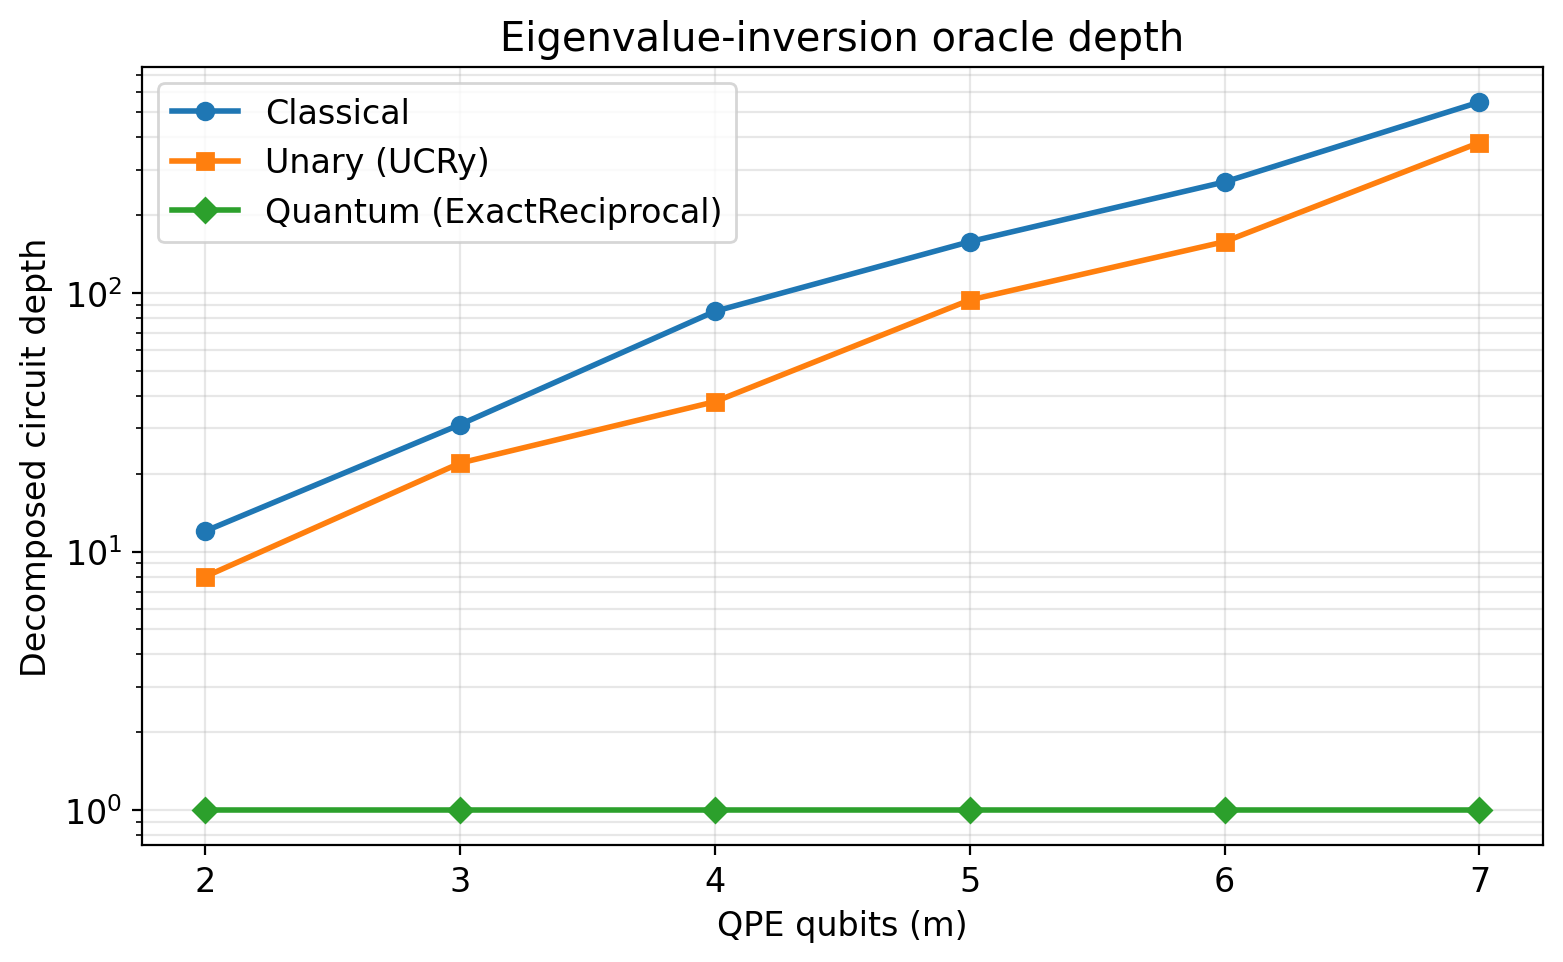

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
markers = ["o", "s", "D"]
for (name, depths), mkr in zip(depth_results.items(), markers):
    ax.plot(m_values, depths, marker=mkr, label=name, linewidth=2)

ax.set_xlabel("QPE qubits (m)")
ax.set_ylabel("Decomposed circuit depth")
ax.set_title("Eigenvalue-inversion oracle depth")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Unitary equivalence sanity check

Verify that the classical and unary oracles produce the exact same unitary for small *m*. The quantum oracle uses a different rotation-angle schedule (no eigenvalue snapping), so it is *not* expected to match.

In [15]:
for m in [2, 3, 4]:
    qpe = QuantumRegister(m, "qpe")
    anc = QuantumRegister(1, "anc")

    circ_cls = QuantumCircuit(qpe, anc)
    circ_uni = QuantumCircuit(qpe, anc)

    t0, C = dynamic_t0(A_2x2), C_factor(A_2x2)
    classical_eig_inversion_oracle(circ_cls, qpe, anc[0], A=A_2x2, t0=t0, C=C)
    unary_iteration_eig_inversion_oracle(circ_uni, qpe, anc[0], A=A_2x2, t0=t0, C=C)

    equiv = Operator(circ_cls).equiv(Operator(circ_uni))
    print(f"m={m}: classical == unary? {equiv}")

m=2: classical == unary? True
m=3: classical == unary? True
m=4: classical == unary? True


## 4. Gate-count breakdown

In [16]:
def gate_counts(oracle_fn, A, m):
    qpe = QuantumRegister(m, "qpe")
    anc = QuantumRegister(1, "anc")
    circ = QuantumCircuit(qpe, anc)
    t0, C = dynamic_t0(A), C_factor(A)
    oracle_fn(circ, qpe, anc[0], A=A, t0=t0, C=C)
    decomposed = circ.decompose()
    counts = {}
    for inst in decomposed.data:
        n = inst.operation.name
        counts[n] = counts.get(n, 0) + 1
    return counts

print("=== m = 4,  A = 2x2 PD ===")
for name, fn in oracles.items():
    gc = gate_counts(fn, A_2x2, 4)
    print(f"  {name:30s}  {gc}")

print("\n=== m = 5,  A = 2x2 PD ===")
for name, fn in oracles.items():
    gc = gate_counts(fn, A_2x2, 5)
    print(f"  {name:30s}  {gc}")

=== m = 4,  A = 2x2 PD ===
  Classical                       {'x': 64, 'c4ry': 15, 'h': 8, 'cx': 24, 'tdg': 12, 't': 16, 'ry': 4}
  Unary (UCRy)                    {'r': 8, 'cx': 30}
  Quantum (ExactReciprocal)       {'ucry': 1}

=== m = 5,  A = 2x2 PD ===
  Classical                       {'x': 160, 'c5ry': 31, 'p': 30, 'cx': 40, 'h': 8, 'ry': 4, 'tdg': 6, 't': 8}
  Unary (UCRy)                    {'r': 32, 'cx': 62}
  Quantum (ExactReciprocal)       {'ucry': 1}


## 5. Full-HHL solution error comparison

Build the complete HHL circuit (state prep, QPE, inversion, uncompute) with each oracle, compute the ideal statevector, and compare to *x* = *A*^(-1)*b*.

We measure error as the fidelity infidelity: 1 - |<x_ideal|x_HHL>|^2, where both vectors are normalised.

In [17]:
def _strip_measurements(circ):
    """Return a copy of circ with all measure/reset ops and classical bits removed."""
    qc = QuantumCircuit(*circ.qregs)
    for inst in circ.data:
        if inst.operation.name in ("measure", "reset"):
            continue
        qc.append(inst.operation, inst.qubits)
    return qc


def hhl_statevector_error(A, b, m, eig_oracle):
    """
    Build a full HHL circuit, compute its statevector, post-select on
    ancilla=1, and return the fidelity error vs the classical solution.
    """
    sp = StatePrep(method="default")
    hhl = HHL(state_prep=sp, readout="measure_x", num_qpe_qubits=m, eig_oracle=eig_oracle)
    circ = hhl.build_circuit(A, b)

    circ_no_meas = _strip_measurements(circ)
    sv = Statevector.from_instruction(circ_no_meas)
    data = sv.data

    n_data = int(np.log2(len(b)))

    # Post-select: ancilla flag (qubit 0) = 1, all other non-data qubits = 0
    # Qubit layout: [ancilla_flag(1), qpe(m), data(n_data)]
    x_hhl = np.zeros(2**n_data, dtype=complex)
    for data_idx in range(2**n_data):
        full_idx = 1 + (data_idx << (1 + m))
        x_hhl[data_idx] = data[full_idx]

    norm = np.linalg.norm(x_hhl)
    if norm < 1e-15:
        return 1.0
    x_hhl /= norm

    x_exact = np.linalg.solve(A, b)
    x_exact /= np.linalg.norm(x_exact)

    fidelity = abs(np.dot(x_exact.conj(), x_hhl)) ** 2
    return 1.0 - fidelity

In [18]:
oracle_tags = {
    "Classical": "classical",
    "Unary (UCRy)": "unary",
    "Quantum (ExactReciprocal)": "quantum",
}

m_values_error = list(range(3, 8))

error_data = {}
for prob_name, (A, b) in problems.items():
    print(f"\n--- {prob_name} ---")
    error_data[prob_name] = {}
    for label, tag in oracle_tags.items():
        errors = []
        for m in m_values_error:
            err = hhl_statevector_error(A, b, m, tag)
            errors.append(err)
        error_data[prob_name][label] = errors
        print(f"  {label:30s}  errors = {[f'{e:.2e}' for e in errors]}")


--- 2×2 (κ≈2.6) ---
  Classical                       errors = ['7.81e-04', '2.40e-04', '1.61e-05', '3.00e-05', '1.26e-06']
  Unary (UCRy)                    errors = ['7.81e-04', '2.40e-04', '1.61e-05', '3.00e-05', '1.26e-06']
  Quantum (ExactReciprocal)       errors = ['1.79e-01', '1.19e-04', '9.86e-04', '6.55e-04', '4.58e-06']

--- 4×4 (κ=5) ---
  Classical                       errors = ['1.23e-03', '1.30e-03', '4.86e-06', '7.85e-06', '3.53e-06']
  Unary (UCRy)                    errors = ['1.23e-03', '1.30e-03', '4.86e-06', '7.85e-06', '3.53e-06']
  Quantum (ExactReciprocal)       errors = ['8.73e-03', '9.41e-02', '5.08e-07', '2.89e-06', '2.74e-06']


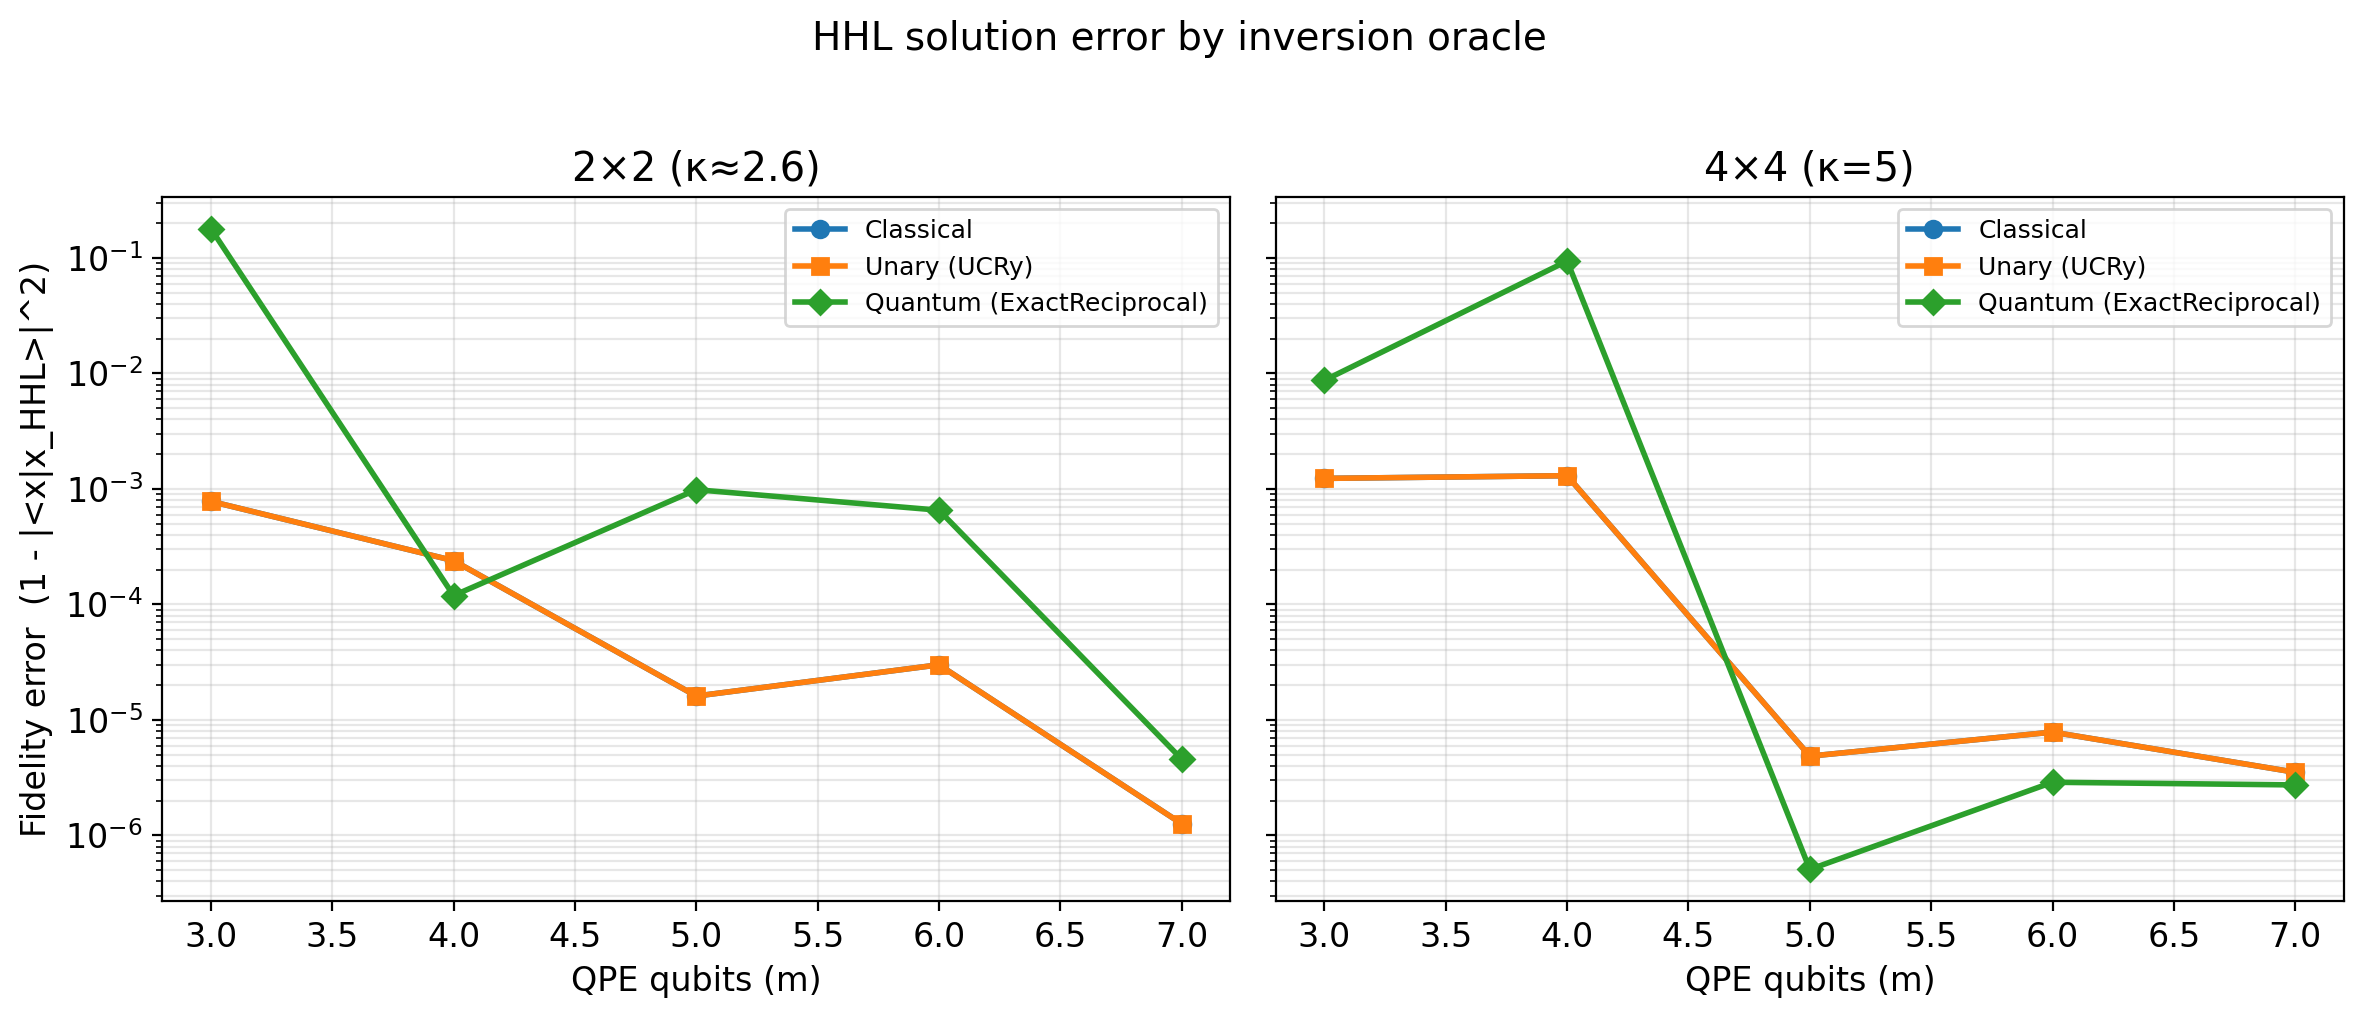

In [19]:
fig, axes = plt.subplots(1, len(problems), figsize=(6 * len(problems), 5), sharey=True)
if len(problems) == 1:
    axes = [axes]

markers = ["o", "s", "D"]

for ax, (prob_name, err_dict) in zip(axes, error_data.items()):
    for (label, errors), mkr in zip(err_dict.items(), markers):
        ax.plot(m_values_error, errors, marker=mkr, label=label, linewidth=2)
    ax.set_xlabel("QPE qubits (m)")
    ax.set_title(prob_name)
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Fidelity error  (1 - |<x|x_HHL>|^2)")
fig.suptitle("HHL solution error by inversion oracle", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

## 6. Full-HHL circuit depth comparison

In [20]:
def full_hhl_depth(A, b, m, eig_oracle):
    sp = StatePrep(method="default")
    hhl = HHL(state_prep=sp, readout="measure_x", num_qpe_qubits=m, eig_oracle=eig_oracle)
    circ = hhl.build_circuit(A, b)
    return circ.decompose().depth()


m_values_full = list(range(3, 7))
A_bench, b_bench = A_2x2, b_2

full_depths = {label: [] for label in oracle_tags}
for m in m_values_full:
    for label, tag in oracle_tags.items():
        d = full_hhl_depth(A_bench, b_bench, m, tag)
        full_depths[label].append(d)
    print(f"m={m}  ", {k: v[-1] for k, v in full_depths.items()})

m=3   {'Classical': 78, 'Unary (UCRy)': 69, 'Quantum (ExactReciprocal)': 48}
m=4   {'Classical': 150, 'Unary (UCRy)': 103, 'Quantum (ExactReciprocal)': 66}
m=5   {'Classical': 241, 'Unary (UCRy)': 177, 'Quantum (ExactReciprocal)': 84}
m=6   {'Classical': 370, 'Unary (UCRy)': 259, 'Quantum (ExactReciprocal)': 102}


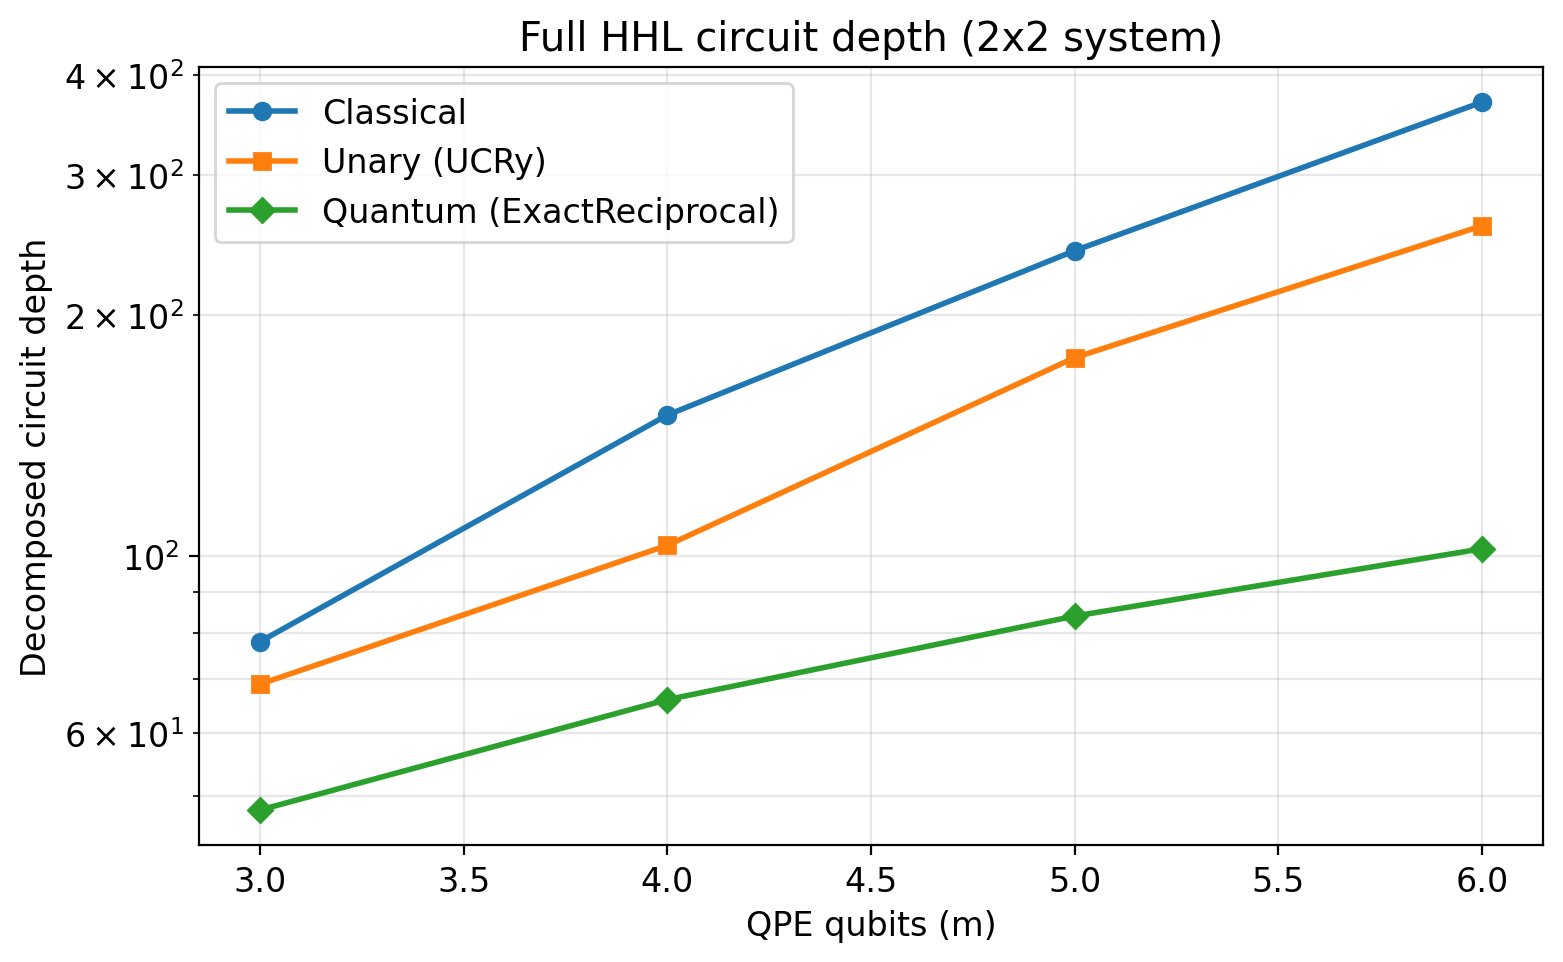

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
for (label, depths), mkr in zip(full_depths.items(), markers):
    ax.plot(m_values_full, depths, marker=mkr, label=label, linewidth=2)

ax.set_xlabel("QPE qubits (m)")
ax.set_ylabel("Decomposed circuit depth")
ax.set_title("Full HHL circuit depth (2x2 system)")
ax.set_yscale("log")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Summary

| Oracle | Inversion depth | Full HHL depth | Solution quality |
|--------|----------------|----------------|------------------|
| **Classical** (brute-force *m*-controlled RY) | O(*m* . 2^*m*) - highest | Dominated by inversion oracle at large *m* | Uses eigenvalue snapping: lowest error for well-resolved eigenvalues |
| **Unary / UCRy** (uniformly controlled rotation) | O(2^*m*) - factor *m* reduction | Noticeable savings at *m* >= 4 | Identical to classical (same angle table) |
| **Quantum** (`ExactReciprocalGate`) | O(*m*) - shallowest | Shallowest overall | No eigenvalue snapping; accuracy depends on how well 1/lambda is approximated by per-bit rotations |

**Key takeaway:** The unary-iteration (UCRy) oracle is a strict improvement over the classical oracle - identical solution quality with O(*m*x) lower depth and zero ancilla overhead. The quantum oracle is exponentially shallower still but uses a different rotation schedule, so the accuracy trade-off depends on the problem.